# Aula 4 - Mais Pandas

Nessa aula, iremos tratar dos seguintes conteúdos:
- Pandas
- Series
- Métodos Pandas
- DataFrames
- Combinando DataFrames
- Trabalhando com CSVs
- GroupBy e Agregadores

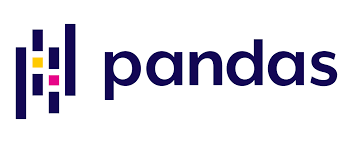

##   

## Pandas

__Pandas__ é um pacote python construído com base no __NumPy__ e __Matplotlib__ que busca organizar dados no formato de tabela, atribuindo rótulos às linhas e colunas. O pacote __Pandas__ fornece ainda um conjunto de funcionalidades que permite processar as informações de tabelas de forma bastante eficiente, implementando métodos fundamentais para fins de tratamento de dados.

O Pandas organiza os dados nos seguintes tipos de estruturas:
- Series (Séries)
- DataFrame

## Combinando DataFrames
__Pandas__ fornece um conjunto de métodos para combinar DataFrames, o que é extremamente útil em cenários envolvendo múltiplas fontes de dados. Em particular, os métodos:
- __merge__ combina DataFrames com base nos rótulos das linhas ou valores das colunas
- __concatenate__ combina DataFrames a partir de um eixo específico

### merge
O método __merge__ "funde" dois DataFrames, duas séries, ou uma série com um DataFrame.

A fuzão pode ser feita com base nos:
- valores de duas colunas específicas, uma em cada DataFrame 
- valores de uma coluna em um dos DataFrame e rótulos das linhas no outro
- valores dos rótulos das linhas em ambos os DataFrames (ou Séries)

#### Merge baseado nos valores de duas colunas

In [1]:
import pandas as pd 

In [3]:
# Construindo dois DataFrames que serão fundidos com o método 'merge'
df1 = pd.DataFrame({'key': ['b','b','a','c','a','a','b'], 
                   'data1': range(7)})

df2 = pd.DataFrame({'key': ['a','b','d','b','d'], 
                   'data2': range(5)})

# Print do primeiro Dataframe
print("df1")
display(df1)

# Print do Segundo Dataframe
print("df2")
display(df2)

df1


,key,data1
0,b,0
1,b,1
2,a,2
3,c,3
4,a,4
5,a,5
6,b,6


df2


,key,data2
0,a,0
1,b,1
2,d,2
3,b,3
4,d,4


In [4]:
# SELECT 
#     d1.key, 
#     d1.data1,
#     d2.data2
# FROM
# df1 AS d1 
# LEFT JOIN df2 as d2 
# ON d1.key = d2.key

In [5]:
pd.merge(df1, df2, on = "key", how = "left")

,key,data1,data2
0,b,0,1.0
1,b,0,3.0
2,b,1,1.0
3,b,1,3.0
4,a,2,0.0
5,c,3,NaN
6,a,4,0.0
7,a,5,0.0
8,b,6,1.0
9,b,6,3.0


In [6]:
df1.merge(df2, on ="key", how = "left")

,key,data1,data2
0,b,0,1.0
1,b,0,3.0
2,b,1,1.0
3,b,1,3.0
4,a,2,0.0
5,c,3,NaN
6,a,4,0.0
7,a,5,0.0
8,b,6,1.0
9,b,6,3.0


# Para casa: 

Faça o left join da tabela df2 com a tabela df1

In [ ]:
# Com o how podemos passar o tipo merge que queremos fazer (left, right, inner, outer)
pd.merge(df1,df2,on='key',how='outer')  

,key,data1,data2
0,b,0.0,1.0
1,b,0.0,3.0
2,b,1.0,1.0
3,b,1.0,3.0
4,b,6.0,1.0
5,b,6.0,3.0
6,a,2.0,0.0
7,a,4.0,0.0
8,a,5.0,0.0
9,c,3.0,NaN


### concat
O método __concat__ é utilizado para juntar DataFrames ou Séries com base em um dos eixos.
- __axis = 0__ concatena por linhas 
- __axis = 1__ concatena por colunas. Quando empregado em um conjunto de séries resulta em um DataFrame

O método assume como parâmetro uma lista de DataFrames ou Séries.

##   

## Trabalhando com CSVs

O __Pandas__ tem algumas funcionalidades bem interessantes, como por exemplo permitir que carregue para o Notebook arquivos no formato csv, excel, xlsx e etc. Vamos ver uma aplicação como o CSV:

In [6]:
# Instala a biblioteca pandas no ambiente do notebook
%pip install pandas

import pandas as pd

# Carrega um arquivo CSV
df = pd.read_csv('titanic.csv')

# Print do DataFrame
df

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [19]:
df2 = pd.read_csv('dataset_trabalho.csv')
df2.tail()

df2.shape

(6894, 15)

In [28]:
df = pd.read_csv('titanic.csv')
df.head()  # Exibe as primeiras linhas do DataFrame

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


[Neste Link](https://www.kaggle.com/c/titanic/data), conseguimos mais informações sobre a base de dados do Titanic! O Kaggle é uma plataforma muito conheciida no quesito de competições de Data Science e Machine Learning, além de disponibilizar diversos conjuntos de dados para treinarmos =)

Vamos testar alguns outros __métodos__ disponíveis para os DaataFrames:

In [29]:
# Mostra as dimensões da DataFrame
df.shape

(891, 12)

__Método head/tail:__ São métodos muito importantes que mostram na tela as primeiras e últimas linhas respectivamente de um __DataFrame__:

In [30]:
# Mostra as primeiras 10 linhas do DataFrame
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [31]:
df.tail()  # Exibe as primeiras linhas do DataFrame

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [32]:
# Mostra as ultimas 10 linhas do DataFrame
df.tail(8)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.500,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.050,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.125,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.450,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.750,NaN,Q


In [33]:
if 'Survived' in df.columns:
	df['Survived']
else:
	print("Coluna 'Survived' não existe. Colunas disponíveis:", df.columns.tolist())

In [34]:
# Mostra a porcentagem de sobreviventes do Titanic
df['Survived'].value_counts(normalize=True)*100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [ ]:
# Mostra a Contagem de Sobreviventes no Titanic
df['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

##    

## GroupBy e Agregadores

Podemos utilizar o __GroupBy__, para fsazer alguns cálculos de agrupamentos específicos (bem parecido com o que fazemos no SQL):

In [ ]:
# Calcula a média de Idade por Sexo
## para agruparmos usamos o metodo group by
## no parentesis passamos uma coluna ou um conjunto de colunas
## Depois precisamos passar entre colchetes o campo que vamos agrupar
## Por fim passamos a metrica que quermos

df.groupby('Sex')['Age'].mean()

Sex
female    27.915709
male      30.726645
Name: Age, dtype: float64

Pode-se também calcular mais de uma métrica por vez utilizando o __GroupBy__ combinado com o método __agg:__

In [ ]:
# Calculo das Métricas para o Agrupamento Sexo e Idade
# Quero calcular muitas metricas na mesma linha
# podemos usar o .agg e passar uma lista de metricas

df.groupby(["Sex"])["Age"].agg([ "mean", "std", "count"])

,mean,std,count
Sex,,,
female,27.915709,14.110146,261
male,30.726645,14.678201,453


In [ ]:
# Com mais de uma categoria dentro do Groupby
# Quero ter mais de uma categoria
# Podemos passar no parentesis uma lista de colunas também

df.groupby(["Sex", "Pclass"])["Age"].agg([ "mean", "std", "count"])

mean        std  count
Sex    Pclass                             
female 1       34.611765  13.612052     85
       2       28.722973  12.872702     74
       3       21.750000  12.729964    102
male   1       41.281386  15.139570    101
       2       30.740707  14.793894     99
       3       26.507589  12.159514    253

In [ ]:
# Mais de uma categoria e mais de uma métrica calculando
# Podemos calcular para um conjunto de dados diferentes as metricas
# basta passar no indexador (no colchete) uma lista de colunas
df.groupby(["Sex", "Pclass"])[["Age", "Survived"]].agg([ "mean", "std", "count", "sum"])

Age                            Survived                  \
                    mean        std count      sum      mean       std count   
Sex    Pclass                                                                  
female 1       34.611765  13.612052    85  2942.00  0.968085  0.176716    94   
       2       28.722973  12.872702    74  2125.50  0.921053  0.271448    76   
       3       21.750000  12.729964   102  2218.50  0.500000  0.501745   144   
male   1       41.281386  15.139570   101  4169.42  0.368852  0.484484   122   
       2       30.740707  14.793894    99  3043.33  0.157407  0.365882   108   
       3       26.507589  12.159514   253  6706.42  0.135447  0.342694   347   

                   
              sum  
Sex    Pclass      
female 1       91  
       2       70  
       3       72  
male   1       45  
       2       17  
       3       47

In [ ]:
df.groupby('Sex')['Survived'].value_counts(normalize=True)*100
# Calcula a média de Idade por Sexo


Sex     Survived
female  1           74.203822
        0           25.796178
male    0           81.109185
        1           18.890815
Name: Survived, dtype: float64

In [ ]:
df.groupby(['Sex', 'Pclass'])['Survived'].value_counts(normalize=True)*100

Sex     Pclass  Survived
female  1       1           96.808511
                0            3.191489
        2       1           92.105263
                0            7.894737
        3       0           50.000000
                1           50.000000
male    1       0           63.114754
                1           36.885246
        2       0           84.259259
                1           15.740741
        3       0           86.455331
                1           13.544669
Name: Survived, dtype: float64

In [ ]:
ibov = pd.read_csv('IBOV.csv')
ibov['Data'] = pd.to_datetime(ibov['Data'])

In [ ]:
ibov.dtypes

Data        datetime64[ns]
Ultimo             float64
Abertura           float64
Maxima             float64
Minima             float64
dtype: object

In [ ]:
ibov

,Data,Ultimo,Abertura,Maxima,Minima
0,2021-12-30,104.822,104.106,105.269,104.106
1,2021-12-29,104.107,104.863,105.190,103.851
2,2021-12-28,104.864,105.555,105.652,104.503
3,2021-12-27,105.554,104.892,105.694,104.798
4,2021-12-23,104.891,105.251,105.453,104.637
...,...,...,...,...,...
242,2021-08-01,125.077,122.387,125.324,122.386
243,2021-07-01,122.386,119.103,122.697,119.101
244,2021-06-01,119.100,119.377,120.924,118.917
245,2021-05-01,119.376,118.835,119.790,116.756


In [ ]:
df_titanic.groupby(["Embarked"])["Fare"].agg(["mean", "sum"])

In [ ]:
pd.pivot_table(df_titanic, values='Fare', index='Pclass', columns='Sex', aggfunc=np.sum)

## Exercícios

### Para o Dataframe do Titanic

**1)** Faça a leitura do Dataframe e mostre as 5 primeiras linhas

In [ ]:
df = pd.read_csv('../datasets/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


**2)** Calcule a tarifa média por Sexo

In [ ]:
df.groupby('Sex')['Fare'].mean()

Sex
female    44.479818
male      25.523893
Name: Fare, dtype: float64

**3)** Determine o passageiro que pagou a maior tarifa

In [ ]:
df[df['Fare'] == df['Fare'].max()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


**4)** Determine a idade média dos sobreviventes

In [ ]:
df.groupby(['Survived'])['Age'].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

In [ ]:
df[df['Survived'] == 1]['Age'].mean()

28.343689655172415

## Exercicios Gerais

**1)** Baixe e carregue em um pd.DataFrame o arquivo "IBOV.csv", que contém as cotações diárias do índice Ibovespa no ultimo ano (2021).

In [ ]:
ibov = pd.read_csv('IBOV.csv')
ibov['Data'] = pd.to_datetime(ibov['Data'])
ibov

,Data,Ultimo,Abertura,Maxima,Minima
0,2021-12-30,104.822,104.106,105.269,104.106
1,2021-12-29,104.107,104.863,105.190,103.851
2,2021-12-28,104.864,105.555,105.652,104.503
3,2021-12-27,105.554,104.892,105.694,104.798
4,2021-12-23,104.891,105.251,105.453,104.637
...,...,...,...,...,...
242,2021-08-01,125.077,122.387,125.324,122.386
243,2021-07-01,122.386,119.103,122.697,119.101
244,2021-06-01,119.100,119.377,120.924,118.917
245,2021-05-01,119.376,118.835,119.790,116.756


**2)** Imprima as três primeiras linhas do DataFrame carregado e depois as três últimas.

In [ ]:
ibov.head(3)

,Data,Ultimo,Abertura,Maxima,Minima
0,2021-12-30,104.822,104.106,105.269,104.106
1,2021-12-29,104.107,104.863,105.190,103.851
2,2021-12-28,104.864,105.555,105.652,104.503


In [ ]:
ibov.tail(3)

,Data,Ultimo,Abertura,Maxima,Minima
244,2021-06-01,119.100,119.377,120.924,118.917
245,2021-05-01,119.376,118.835,119.790,116.756
246,2021-04-01,118.855,119.024,120.354,118.062


**3)** Imprima o maior e o menor valor de fechamento do índice no período analisado.

In [ ]:
ibov['Ultimo'].max()

130.776

In [ ]:
ibov['Ultimo'].min()

100.775

**4)** Qual é o dia associado à 50ª linha do DataFrame?

In [ ]:
ibov.loc[49, 'Data']

Timestamp('2021-10-19 00:00:00')

**5)** Compare a média do valor de fechamento do índice entre o primeiro e o segundo trimestre do ano estudado. Em qual dos períodos verifica-se maior média?

In [ ]:
df_primeiro_trimestre = ibov[(ibov['Data'] >= '2021-01-01') & (ibov['Data'] < '2021-04-01')]
df_primeiro_trimestre.sort_values(by='Data', inplace=True)
df_primeiro_trimestre

c:\program files\python39\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


,Data,Ultimo,Abertura,Maxima,Minima
227,2021-01-02,117.518,115.093,117.862,115.093
209,2021-01-03,110.335,110.036,112.445,110.036
186,2021-01-04,115.253,116.644,117.088,114.991
145,2021-01-06,128.267,126.218,128.363,126.218
124,2021-01-07,125.666,126.802,127.204,124.994
81,2021-01-09,119.396,118.793,119.942,118.067
60,2021-01-10,112.900,110.980,113.020,110.980
40,2021-01-11,105.551,103.514,106.136,103.514
20,2021-01-12,100.775,101.916,104.087,100.727
239,2021-01-13,121.933,123.996,124.032,121.016


In [ ]:
df_segundo_trimestre = ibov[(ibov['Data'] >= '2021-04-01') & (ibov['Data'] < '2021-07-01')]
df_segundo_trimestre.sort_values(by='Data', inplace=True)
df_segundo_trimestre

c:\program files\python39\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


,Data,Ultimo,Abertura,Maxima,Minima
246,2021-04-01,118.855,119.024,120.354,118.062
224,2021-04-02,119.261,119.728,120.560,118.918
206,2021-04-03,112.690,111.191,114.433,111.163
165,2021-04-05,117.712,119.209,119.293,117.631
143,2021-04-06,130.126,129.600,130.137,129.148
...,...,...,...,...,...
129,2021-06-24,129.514,128.433,129.541,128.428
128,2021-06-25,127.256,129.513,129.748,126.697
127,2021-06-28,127.429,127.255,128.067,126.629
126,2021-06-29,127.327,127.429,127.507,126.184


In [ ]:
media_1trim = df_primeiro_trimestre['Ultimo'].mean()
media_2trim = df_segundo_trimestre['Ultimo'].mean()

print('Media do primeiro tri :', media_1trim)
print('Media do segundo tri :', media_2trim)

Media do primeiro tri : 116.33892857142857
Media do segundo tri : 121.349890625


**6)** Acrescente uma coluna ao DataFrame chamada 'amplitude', contendo a variação máxima diária, isto é, valor máximo - valor mínimo. Imprima a linha onde se teve a maior variação do índice e depois salve o DataFrame modificado no arquivo "BVSP_mod.csv".

In [ ]:
ibov['Amplitude'] = ibov['Maxima'] - ibov['Minima']
ibov.head()

,Data,Ultimo,Abertura,Maxima,Minima,Amplitude
0,2021-12-30,104.822,104.106,105.269,104.106,1.163
1,2021-12-29,104.107,104.863,105.190,103.851,1.339
2,2021-12-28,104.864,105.555,105.652,104.503,1.149
3,2021-12-27,105.554,104.892,105.694,104.798,0.896
4,2021-12-23,104.891,105.251,105.453,104.637,0.816


In [ ]:
ibov.sort_values(by=['Amplitude'], ascending=False)
print(ibov.loc[214])

Data         2021-02-22 00:00:00
Ultimo                   112.668
Abertura                 118.388
Maxima                   118.388
Minima                    111.65
Amplitude                  6.738
Name: 214, dtype: object


In [ ]:
indice_maior = ibov['Amplitude'].argmax()
ibov.loc[indice_maior]

Data         2021-02-22 00:00:00
Ultimo                   112.668
Abertura                 118.388
Maxima                   118.388
Minima                    111.65
Amplitude                  6.738
Name: 214, dtype: object

##  

## Links, Artigos e Referências:

- [Documentação do Pandas](https://pandas.pydata.org/docs/), documentação onde vocês podem encontrar mais informações sobre os métodos e funções do Pandas e descobrir novos métodos que não foram apresentados no curso;
- ["10 Python Pandas Tricks that make your work more efficient",](https://towardsdatascience.com/10-python-pandas-tricks-that-make-your-work-more-efficient-2e8e483808ba) artigo escrito pelo Towards Data Science;
- ["28 useful Pandas functions you might not know"](https://paulovasconcellos.com.br/28-useful-pandas-functions-you-might-not-know-de42c59db085https://medium.com/@zachary.bedell/writing-beautiful-code-with-numpy-505f3b353174), artigo escrito por Paulo Vasconcellos para o Data Hackers;